In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

#LOAD THE DATASET

In [7]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**EDA**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


CHECK MISSING **VALUES**

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#DATA CLEANING

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#**ENCODE** CATEGORICAL VALUES

In [12]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

df["Sex"]= le.fit_transform(df["Sex"])
df["Embarked"]= le.fit_transform(df["Embarked"])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


SELECT FEATURES AND TARGET VARIABLES

In [14]:
X = df[["Pclass" , "Sex" , "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

SPLIT THE DATA INTO TRAIN AND TEST

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


TRAIN THE LOGISTIC REGRESSION

In [17]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

MAKE PREDICTIONS

In [18]:
y_pred = model.predict(X_test)

In [19]:
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [20]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [21]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



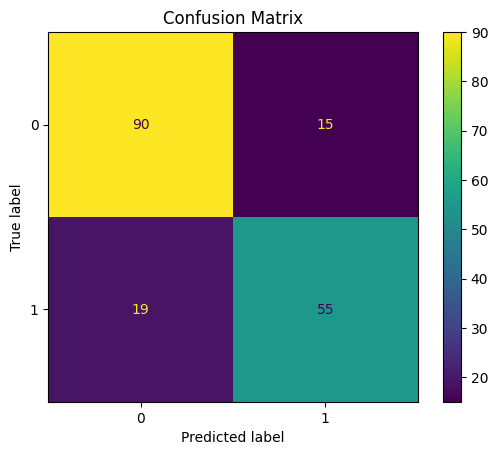

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

EVALUATE THE MODEL

In [27]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
print(feature_importance.sort_values(by='Importance', ascending=False))


    Feature  Importance
5      Fare    0.002534
2       Age   -0.030433
4     Parch   -0.111850
6  Embarked   -0.218778
3     SibSp   -0.293906
0    Pclass   -0.930679
1       Sex   -2.596995


VISUALISATION

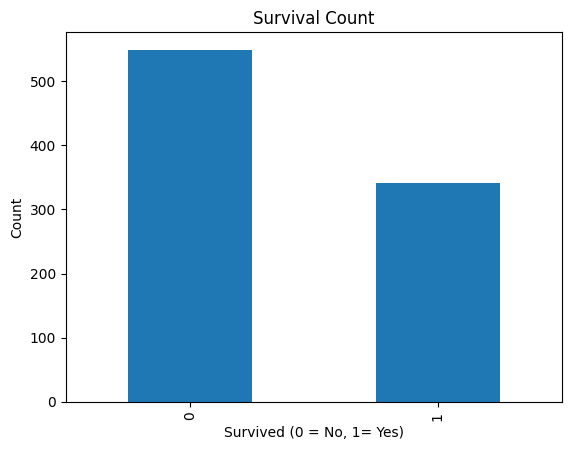

In [28]:
import matplotlib.pyplot as plt
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1= Yes)")
plt.ylabel("Count")
plt.show()

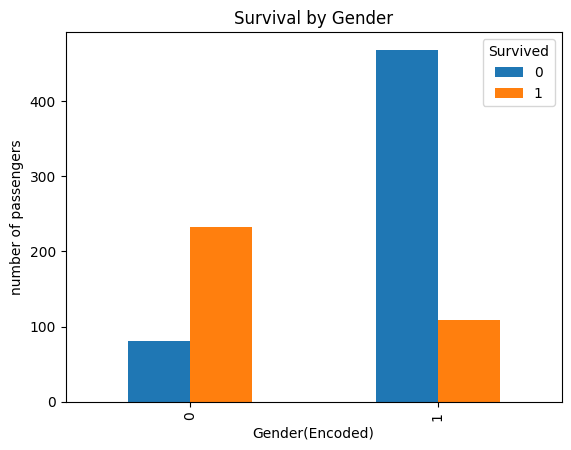

In [29]:
import pandas as pd
pd.crosstab(df["Sex"],df["Survived"]).plot(kind="bar")
plt.title("Survival by Gender")
plt.xlabel("Gender(Encoded)")
plt.ylabel("number of passengers")
plt.show()


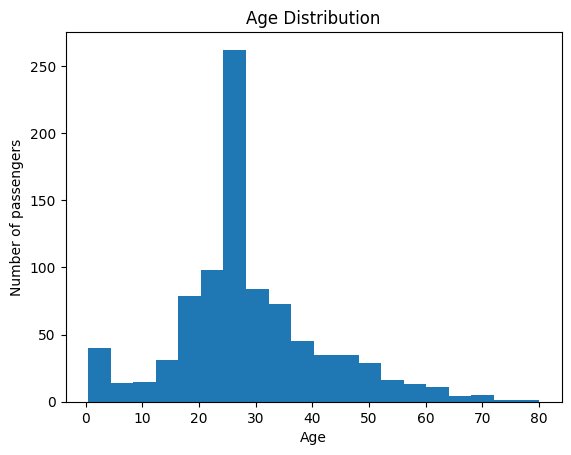

In [30]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.show()

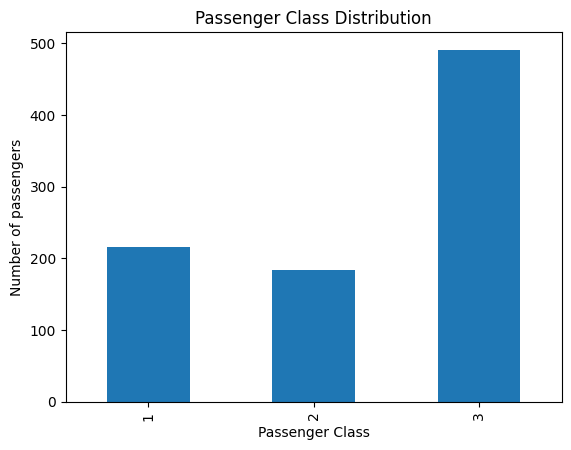

In [31]:
df["Pclass"].value_counts().sort_index().plot(kind = "bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of passengers")
plt.show()

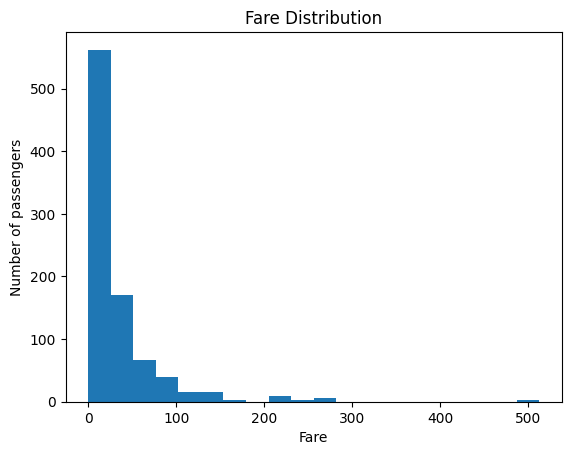

In [32]:
plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of passengers")
plt.show()

#**CONCLUSION**

In this project, I build a Logistic Regression model to predict qhether a titanic passenger survived. I performed data preprocessing by handling missing values, encoding categorical values, selecting relevant features,and splitting the data into training and testing sets. The model was evaluated using accuracy, a confusion matrix, and a classification report. This project demonstrates the complete workflow of a binary classification problem in Machine Learning.